In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

In [2]:
# Set random seeds for reproducibility
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [3]:
transform= transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [4]:
train_data = datasets.ImageFolder(
    "../dataset/train",
    transform=transform
)
test_data= datasets.ImageFolder(
    "../dataset/test",
    transform=transform
)

print("Classes:", train_data.classes)
print("Training images:", len(train_data))
print("Validation source images:", len(train_data))
print("Test images:", len(test_data))

Classes: ['Mild Impairment', 'Moderate Impairment', 'No Impairment', 'Very Mild Impairment']
Training images: 10109
Validation source images: 10109
Test images: 1279


In [5]:
targets = np.array(
    train_data.targets
)

indices = np.arange(
    len(train_data)
)

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=targets    
)

print("Training samples:", len(train_indices))
print("Validation samples:", len(val_indices))

Training samples: 8087
Validation samples: 2022


In [6]:
train_subset = Subset(
    train_data,
    train_indices
)

val_subset = Subset(
    train_data,
    val_indices
)

print(
    "Train subset:",
    len(train_subset)
)

print(
    "Validation subset:",
    len(val_subset)
)

Train subset: 8087
Validation subset: 2022


In [7]:
train_loader= DataLoader(
    train_subset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=16,
    shuffle=False
)

test_loader = DataLoader(
    test_data,
    batch_size=16,
    shuffle=False
)

print("DataLoaders created.")

DataLoaders created.


In [8]:
from collections import Counter

train_labels = [
    train_data.targets[i]
    for i in train_indices
]

val_labels = [
    train_data.targets[i]
    for i in val_indices
]

print("TRAIN DISTRIBUTION")
print(Counter(train_labels))

print("\nVALIDATION DISTRIBUTION")
print(Counter(val_labels))

print("\nTEST DISTRIBUTION")
print(Counter(test_data.targets))

TRAIN DISTRIBUTION
Counter({0: 2047, 3: 2046, 1: 2011, 2: 1983})

VALIDATION DISTRIBUTION
Counter({0: 512, 3: 512, 1: 502, 2: 496})

TEST DISTRIBUTION
Counter({2: 640, 3: 448, 0: 179, 1: 12})


In [9]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("First 10 labels:", labels[:10])

Images shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])
First 10 labels: tensor([0, 1, 1, 0, 0, 0, 3, 0, 1, 3])


In [10]:
class CNNWithDropout(nn.Module):
    def __init__(self, num_classes=4):
        super(CNNWithDropout, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [11]:
model = CNNWithDropout(num_classes=4).to(device)

print(model)

CNNWithDropout(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=4, bias=True)
  )
)


In [12]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [13]:
num_epochs = 10

for epoch in range(num_epochs):

    # ----- Training -----
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = correct / total

    # ----- Validation -----
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / val_total
    val_accuracy = val_correct / val_total

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch [1/10] Train Loss: 0.6929 Train Acc: 0.7052 Val Loss: 0.3363 Val Acc: 0.8511
Epoch [2/10] Train Loss: 0.3216 Train Acc: 0.8686 Val Loss: 0.2008 Val Acc: 0.9169
Epoch [3/10] Train Loss: 0.1918 Train Acc: 0.9227 Val Loss: 0.1858 Val Acc: 0.9224
Epoch [4/10] Train Loss: 0.1203 Train Acc: 0.9545 Val Loss: 0.1128 Val Acc: 0.9560
Epoch [5/10] Train Loss: 0.0903 Train Acc: 0.9661 Val Loss: 0.1032 Val Acc: 0.9634
Epoch [6/10] Train Loss: 0.0606 Train Acc: 0.9781 Val Loss: 0.0991 Val Acc: 0.9693
Epoch [7/10] Train Loss: 0.0616 Train Acc: 0.9769 Val Loss: 0.1014 Val Acc: 0.9624
Epoch [8/10] Train Loss: 0.0583 Train Acc: 0.9790 Val Loss: 0.1162 Val Acc: 0.9590
Epoch [9/10] Train Loss: 0.0606 Train Acc: 0.9776 Val Loss: 0.0828 Val Acc: 0.9723
Epoch [10/10] Train Loss: 0.0380 Train Acc: 0.9855 Val Loss: 0.0749 Val Acc: 0.9773


In [14]:
model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predictions = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

In [15]:
test_accuracy = accuracy_score(all_labels, all_predictions)
test_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Macro F1 Score: {test_f1:.4f}")

Test Accuracy: 0.9609
Macro F1 Score: 0.9714


In [16]:
print(classification_report(
    all_labels,
    all_predictions,
    target_names=train_data.classes
))

                      precision    recall  f1-score   support

     Mild Impairment       0.97      0.97      0.97       179
 Moderate Impairment       1.00      1.00      1.00        12
       No Impairment       0.97      0.97      0.97       640
Very Mild Impairment       0.95      0.95      0.95       448

            accuracy                           0.96      1279
           macro avg       0.97      0.97      0.97      1279
        weighted avg       0.96      0.96      0.96      1279



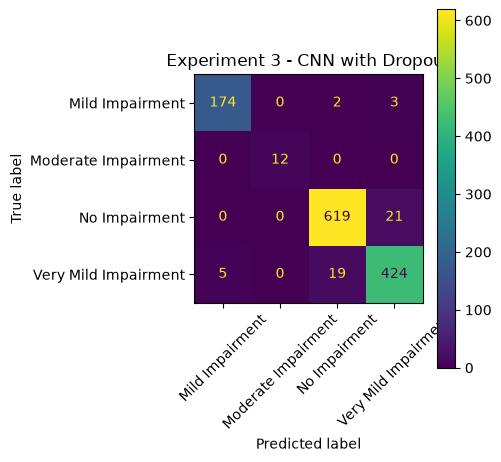

In [17]:
cm = confusion_matrix(all_labels, all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_data.classes
)

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Experiment 3 - CNN with Dropout")
plt.tight_layout()
plt.show()